In [7]:
import pandas as pd
import numpy as np
import multiprocessing as mp
import matplotlib.pyplot as plt
import json
import seaborn as sns
from catomatic.BinaryCatalogue import BinaryBuilder
import matplotlib
from collections import defaultdict
from matplotlib.collections import PolyCollection
from itertools import product
from statsmodels.stats.proportion import proportions_ztest
import numpy as np

from matplotlib.collections import PolyCollection

from protocols import utils, functions, graphs

plt.rcParams['figure.dpi'] = 200
plt.rcParams['font.family'] = 'Helvetica'  
plt.rcParams['font.size'] = 7 
plt.rcParams['figure.figsize'] = (6.69, 5.02)

%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


# Determine the effect of FRS when building and predicting

## Import data and init

In [ ]:
# the path to the CRyPTIC v3.1.0 data tables (including the DST_MEASUREMENTS_+.pkl which has DST for the validation samples appended)
cryptic_tables_path = 'data/cryptic-tables-v3.4.0/'

#read in genes relevant to each drug
with open('data/drug_to_genes.json', 'r') as f:
    drug_genes = json.load(f)

# whether to run the processes which take a long time
run_long_processes = False

# number of cores
n_cores = 8

In [9]:
#read in optimal catalogues determined in 02-gred-search.ipynb
opt_cats = pd.read_csv('results/grid_search/opt_cats_MTBC-CRyPTICv1.1.1-2025.8.csv')
opt_cats

,DRUG,BACKGROUND_RATE,p_value,SENSITIVITY,SPECIFICITY,DPR,SENSITIVITY2,SPECIFICITY2,Score,R,S,U,Total,catalogue
0,RIF,0.20,0.90,0.961417,0.985268,0.971120,0.943997,0.985760,0.970513,42,16,352,410,MTBC-CRyPTICv1.1.1-2025.8
1,INH,0.25,0.90,0.945534,0.987895,0.956970,0.917435,0.988510,0.960530,62,23,626,711,MTBC-CRyPTICv1.1.1-2025.8
2,STM,0.15,0.90,0.954290,0.931818,0.914743,0.896104,0.938396,0.939639,115,8,542,665,MTBC-CRyPTICv1.1.1-2025.8
3,LEV,0.25,0.90,0.923222,0.971103,0.932654,0.894161,0.973286,0.939473,13,19,330,362,MTBC-CRyPTICv1.1.1-2025.8
4,MXF,0.25,0.95,0.940669,0.941006,0.931879,0.914180,0.945520,0.939012,11,22,489,522,MTBC-CRyPTICv1.1.1-2025.8
5,EMB,0.25,0.90,0.947307,0.919858,0.908448,0.875294,0.927433,0.931300,20,58,1056,1134,MTBC-CRyPTICv1.1.1-2025.8
6,PZA,0.05,0.90,0.863924,0.972718,0.976187,0.855799,0.973436,0.919015,440,0,143,583,MTBC-CRyPTICv1.1.1-2025.8
7,AMI,0.05,0.90,0.874486,0.982756,0.921091,0.851703,0.984194,0.916288,11,6,383,400,MTBC-CRyPTICv1.1.1-2025.8
8,CAP,0.05,0.90,0.840217,0.976051,0.922950,0.808577,0.977981,0.897514,43,2,234,279,MTBC-CRyPTICv1.1.1-2025.8
9,ETH,0.05,0.90,0.908987,0.869838,0.896154,0.823346,0.883667,0.894676,298,0,325,623,MTBC-CRyPTICv1.1.1-2025.8


## Calculate performance when built and tested at each FRS

In [10]:
build_frs_values = np.arange(0.1, 1.0, 0.1)
test_frs_values = np.arange(0.1, 1.0, 0.1)

# Shared memory dictionaries for storing results
manager = mp.Manager()
sensitivity_matrix = manager.dict()
specificity_matrix = manager.dict()
dpr_matrix = manager.dict()
sensitivity2_matrix = manager.dict()
specificity2_matrix = manager.dict()

def process_drug_frs(args):

    drug, build_FRS = args

    mutations = functions.prep_mutations('data/mutations-v3.4.0/', 
                                    drug_genes[drug]['genes'], 
                                    version='v3.4.0', 
                                    mut_path=cryptic_tables_path+'MUTATIONS.parquet', 
                                    var_path=cryptic_tables_path+'VARIANTS.parquet', 
                                    train=True)
    
    test_mutations = functions.prep_mutations('data/mutations-v3.4.0/', 
                                    drug_genes[drug]['genes'], 
                                    version='v3.4.0', 
                                    mut_path=cryptic_tables_path+'MUTATIONS.parquet', 
                                    var_path=cryptic_tables_path+'VARIANTS.parquet', 
                                    train=False)
    
    phenotypes = functions.prep_phenotypes(
        drug,
        cryptic_tables_path+"DST_MEASUREMENTS.parquet",
        cryptic_tables_path+"GENOMES.parquet",
        cryptic_tables_path+"WGS_SAMPLES.parquet",
        'v3.4.0',
        validation=False
    )
    
    background, p = opt_cats.loc[opt_cats.DRUG == drug, ['BACKGROUND_RATE', 'p_value']].iloc[0]
    sens_results, spec_results, cov_results, sens2_results, spec2_results = {}, {}, {}, {}, {}
    

    catfile = f"./catalogues/MTBC-CRyPTICv1.1.1-2025.8/frs/{drug.lower()}/bg_{background}_p_{p}_FRS_{np.round(build_FRS,1)}.csv"
    catalogue = BinaryBuilder(samples=phenotypes, mutations=mutations, FRS=build_FRS, seed=drug_genes[drug]['phylogenetic']).build(
        test='Binomial', background=background, strict_unlock=True, p=p
    )
    print(f'{drug}-{background}-{p}-{np.round(build_FRS, 1)}')
    catalogue.to_piezo(
        genbank_ref='NC00962.3',
        catalogue_name=f'{drug}-{background}-{p}-{np.round(build_FRS, 1)}',
        version='0.0',
        drug=drug,
        wildcards=f"./data/wildcards/{drug.lower()}_wildcards.json",
        json_dumps=True,
        outfile=catfile
    )

    sens_results[build_FRS], spec_results[build_FRS], cov_results[build_FRS] = {}, {}, {}
    sens2_results[build_FRS], spec2_results[build_FRS] = {}, {} 

    for test_FRS in test_frs_values:
        all_data = pd.merge(
            phenotypes,
            test_mutations[test_mutations.FRS >= test_FRS],
            on=['UNIQUEID'],
            how='left'
        )
        print (drug, build_FRS, test_FRS)
        _, cov, sens, spec, sens2, spec2 = utils.piezo_predict(iso_df=all_data, drug=drug, catalogue_file=catfile)
        sens_results[build_FRS][test_FRS] = sens * 100
        spec_results[build_FRS][test_FRS] = spec * 100
        cov_results[build_FRS][test_FRS] = cov * 100
        sens2_results[build_FRS][test_FRS] = sens2 * 100
        spec2_results[build_FRS][test_FRS] = spec2 * 100


    sensitivity_matrix[(drug, build_FRS)] = sens_results[build_FRS]
    specificity_matrix[(drug, build_FRS)] = spec_results[build_FRS]
    dpr_matrix[(drug, build_FRS)] = cov_results[build_FRS]
    sensitivity2_matrix[(drug, build_FRS)] = sens2_results[build_FRS]
    specificity2_matrix[(drug, build_FRS)] = spec2_results[build_FRS]


def convert_to_dataframe(matrix, metric):
    data = []
    for (drug, build_FRS), test_results in matrix.items():
        for test_FRS, value in test_results.items():
            data.append([drug, build_FRS, test_FRS, value])
    df = pd.DataFrame(data, columns=['Drug', 'Build_FRS', 'Test_FRS', metric])
    df.set_index(['Drug', 'Build_FRS', 'Test_FRS'], inplace=True)
    return df



# Use weighted score to choose best performing catalogue

In [11]:
# Parallel execution
if run_long_processes:

    mp.set_start_method('fork', force=True)
    all_tasks = list(product(opt_cats.DRUG.values, build_frs_values))
    with mp.Pool(n_cores) as pool:
        pool.map(process_drug_frs, all_tasks)

    sensitivity_df = convert_to_dataframe(sensitivity_matrix, 'Sensitivity')
    specificity_df = convert_to_dataframe(specificity_matrix, 'Specificity')
    dpr_df = convert_to_dataframe(dpr_matrix, 'DPR')
    sensitivity2_df = convert_to_dataframe(sensitivity2_matrix, 'Sensitivity2')
    specificity2_df = convert_to_dataframe(specificity2_matrix, 'Specificity2')

    perf_df = sensitivity_df.join(specificity_df).join(dpr_df).join(sensitivity2_df).join(specificity2_df)

    #perf_df.to_csv('results/frs/MTBC-CRyPTICv1.1.1-2025.8_train_perf.csv', index=True)

else:
    
    perf_df = pd.read_csv('results/frs/MTBC-CRyPTICv1.1.1-2025.8_train_perf.csv')


#format results 
perf_df.reset_index(inplace=True)
catalogued_R, catalogued_S, catalogued_RS = [], [], []
for i in perf_df.index:
    drug = perf_df['Drug'][i]
    background = opt_cats[opt_cats.DRUG==drug].BACKGROUND_RATE.values[0]
    p = opt_cats[opt_cats.DRUG==drug].p_value.values[0]
    build_FRS = perf_df['Build_FRS'][i]
    catfile = f"./catalogues/MTBC-CRyPTICv1.1.1-2025.8/frs/{drug.lower()}/bg_{background}_p_{p}_FRS_{np.round(build_FRS,1)}.csv"
    cat = pd.read_csv(catfile)
    catalogued_R.append(cat[(cat.PREDICTION == 'R') & (~cat.MUTATION.str.contains(r'\*'))].MUTATION.nunique())
    catalogued_S.append(cat[(cat.PREDICTION == 'S') & (~cat.MUTATION.str.contains(r'\*'))].MUTATION.nunique())
    catalogued_RS.append(cat[(cat.PREDICTION.isin(['R', 'S'])) & (~cat.MUTATION.str.contains(r'\*'))].MUTATION.nunique())
perf_df['catalogued_R'] = catalogued_R
perf_df['catalogued_S'] = catalogued_S
perf_df['catalogued_RS'] = catalogued_RS

perf_df


LEV-0.25-0.9-0.9
OUTFILE ./catalogues/MTBC-CRyPTICv1.1.1-2025.8/frs/lev/bg_0.25_p_0.9_FRS_0.9.csv
LEV-0.25-0.9-0.4
OUTFILE ./catalogues/MTBC-CRyPTICv1.1.1-2025.8/frs/lev/bg_0.25_p_0.9_FRS_0.4.csv
LEV 0.9 0.1
LEV 0.4 0.1
STM-0.15-0.9-0.3
OUTFILE ./catalogues/MTBC-CRyPTICv1.1.1-2025.8/frs/stm/bg_0.15_p_0.9_FRS_0.3.csv
STM-0.15-0.9-0.8
STM 0.30000000000000004 OUTFILE 0.1
./catalogues/MTBC-CRyPTICv1.1.1-2025.8/frs/stm/bg_0.15_p_0.9_FRS_0.8.csv
STM 0.8 0.1
RIF-0.2-0.9-0.6
OUTFILE ./catalogues/MTBC-CRyPTICv1.1.1-2025.8/frs/rif/bg_0.2_p_0.9_FRS_0.6.csv
RIF 0.6000000000000001 0.1
RIF-0.2-0.9-0.1
OUTFILE ./catalogues/MTBC-CRyPTICv1.1.1-2025.8/frs/rif/bg_0.2_p_0.9_FRS_0.1.csv
RIF 0.1 0.1
INH-0.25-0.9-0.7
OUTFILE ./catalogues/MTBC-CRyPTICv1.1.1-2025.8/frs/inh/bg_0.25_p_0.9_FRS_0.7.csv
INH 0.7000000000000001 0.1
INH-0.25-0.9-0.2
OUTFILE ./catalogues/MTBC-CRyPTICv1.1.1-2025.8/frs/inh/bg_0.25_p_0.9_FRS_0.2.csv
INH 0.2 0.1
STM 0.8 0.2
STM 0.30000000000000004 0.2
LEV 0.9 0.2
LEV 0.4 0.2
STM 0.8 0.3000

,Drug,Build_FRS,Test_FRS,Sensitivity,Specificity,DPR,Sensitivity2,Specificity2,catalogued_R,catalogued_S,catalogued_RS
0,STM,0.3,0.1,95.443925,93.024823,91.675939,89.918556,93.687100,117,8,125
1,STM,0.3,0.2,95.259225,93.078304,91.766342,89.786485,93.727763,117,8,125
2,STM,0.3,0.3,95.162421,93.127032,91.780250,89.632401,93.768425,117,8,125
3,STM,0.3,0.4,94.952092,93.183857,91.787204,89.434295,93.819254,117,8,125
4,STM,0.3,0.5,94.763908,93.219769,91.801113,89.236188,93.849751,117,8,125
...,...,...,...,...,...,...,...,...,...,...,...
1291,EMB,0.5,0.5,93.844641,92.332365,91.540356,86.371041,92.988268,20,54,74
1292,EMB,0.5,0.6,93.493218,92.375820,91.641791,86.081448,93.019324,20,54,74
1293,EMB,0.5,0.7,93.242978,92.420989,91.691059,85.918552,93.057281,20,54,74
1294,EMB,0.5,0.8,92.796860,92.469029,91.731633,85.574661,93.098689,20,54,74


In [12]:
#filter for drug
drug_df = perf_df[perf_df["Drug"] == 'CAP'].copy()

# Round Build_FRS to 2 decimals to avoid float noise
drug_df["Build_FRS"] = drug_df["Build_FRS"].round(2)

# Drop duplicates AFTER rounding
drug_df = (
    drug_df
    .drop_duplicates(subset=["Build_FRS"])
    .sort_values("Build_FRS")
)
drug_df

,Drug,Build_FRS,Test_FRS,Sensitivity,Specificity,DPR,Sensitivity2,Specificity2,catalogued_R,catalogued_S,catalogued_RS
603,CAP,0.1,0.1,84.021739,97.605098,92.295025,80.857741,97.798148,43,2,45
648,CAP,0.2,0.1,84.039088,97.605098,92.303692,80.962343,97.798148,44,2,46
693,CAP,0.3,0.1,84.021739,97.605098,92.295025,80.857741,97.798148,43,2,45
549,CAP,0.4,0.1,84.021739,97.605098,92.295025,80.857741,97.798148,43,2,45
594,CAP,0.5,0.1,84.021739,97.605098,92.295025,80.857741,97.798148,43,2,45
639,CAP,0.6,0.1,83.986928,97.605098,92.277691,80.648536,97.798148,41,2,43
684,CAP,0.7,0.1,83.969466,97.605098,92.269024,80.543933,97.798148,40,2,42
729,CAP,0.8,0.1,84.285714,97.545043,90.145606,80.230126,97.798148,37,1,38
567,CAP,0.9,0.1,84.268427,97.545043,90.136939,80.125523,97.798148,37,1,38


## Plot bar charts of number of R or S classifications for each drug

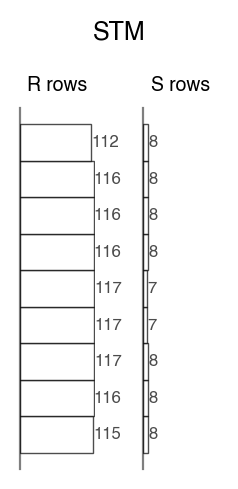

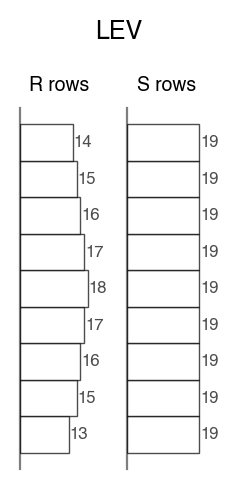

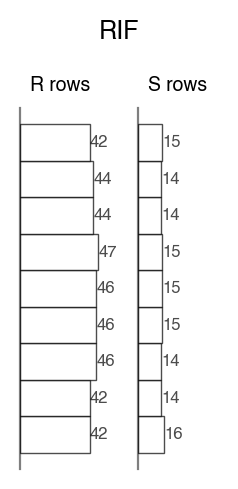

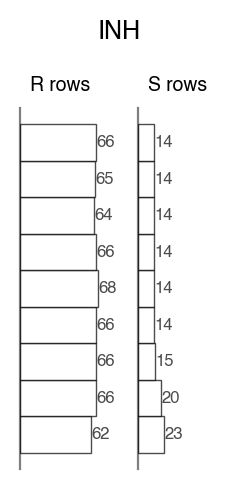

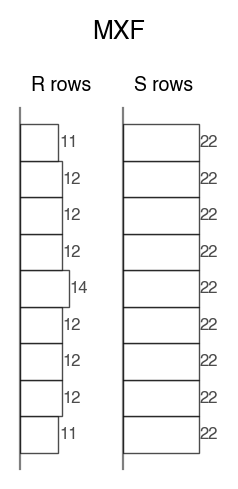

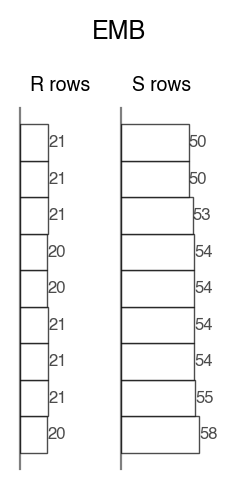

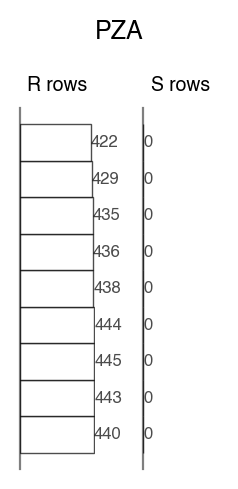

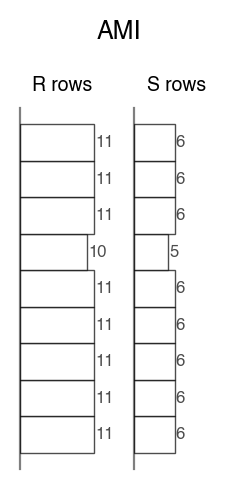

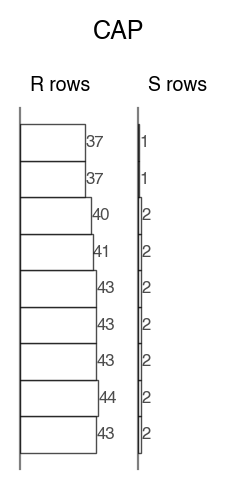

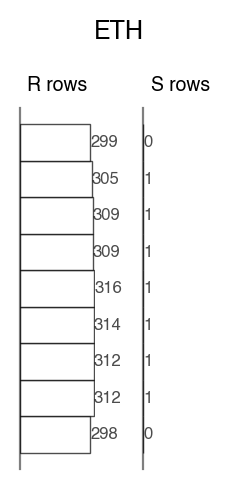

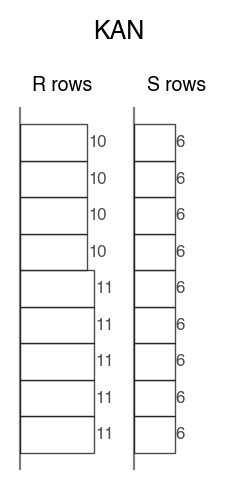

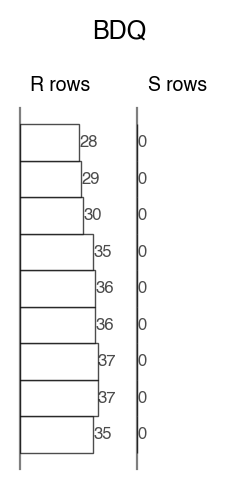

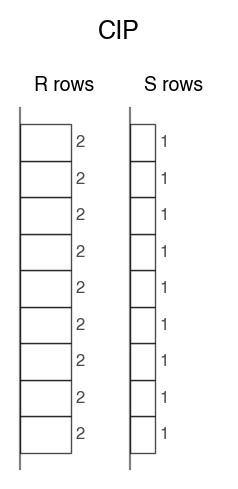

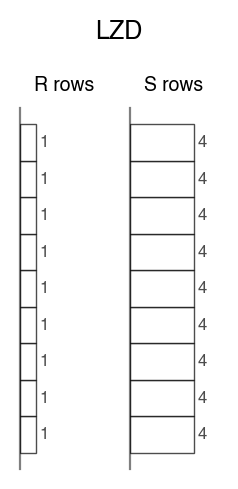

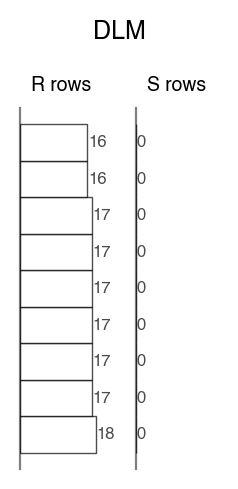

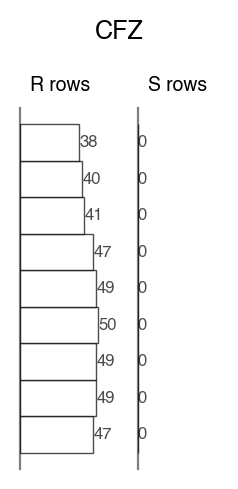

In [13]:
graphs.plot_catalogue_bar_charts(perf_df)

## Plot heatmaps of sensitivity, specificity, and DPR for the FRS the catalogues are built at vs tested at

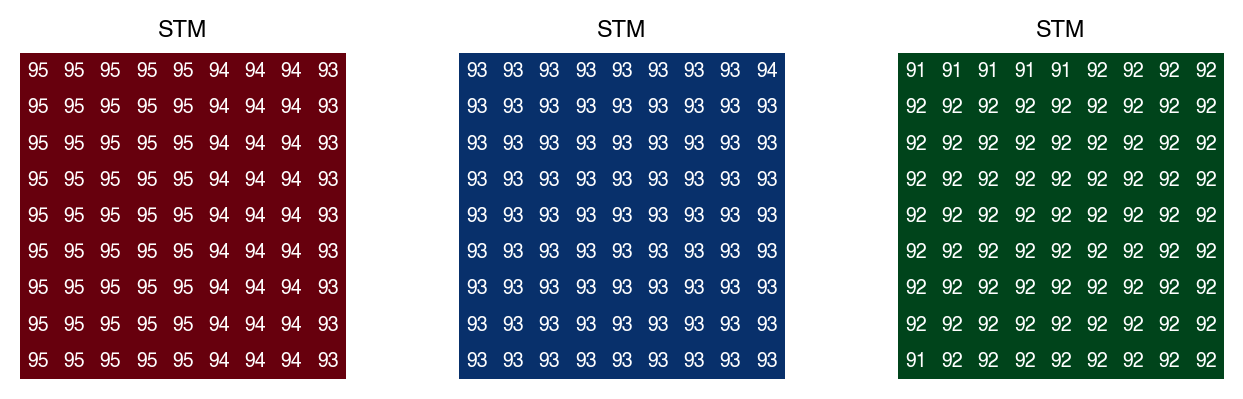

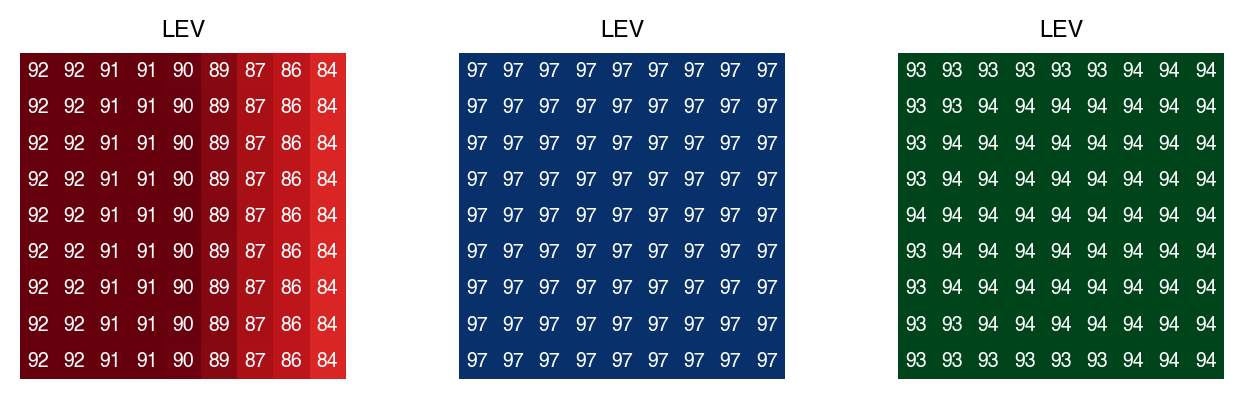

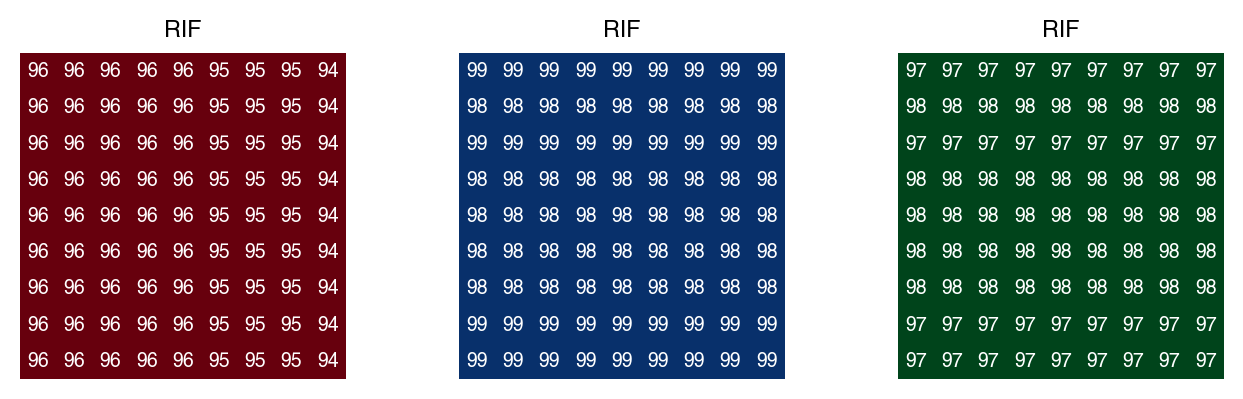

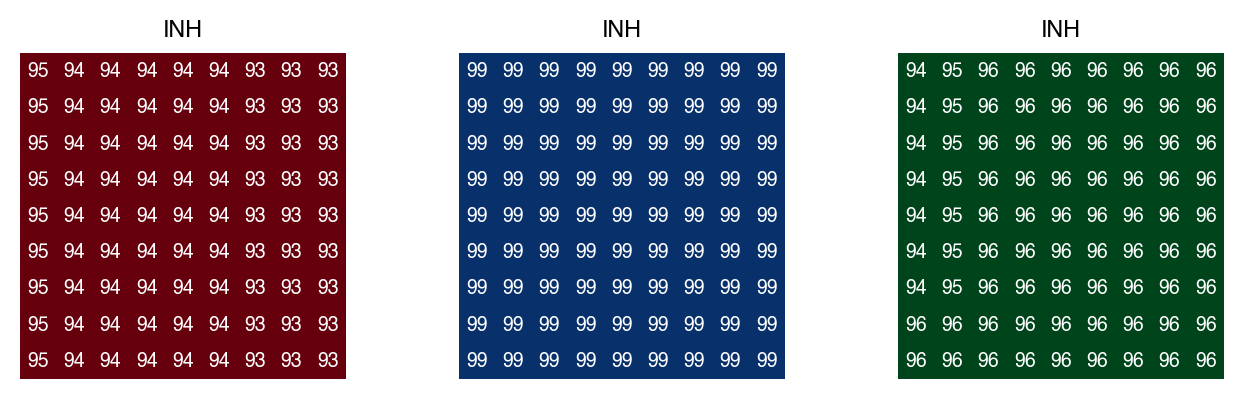

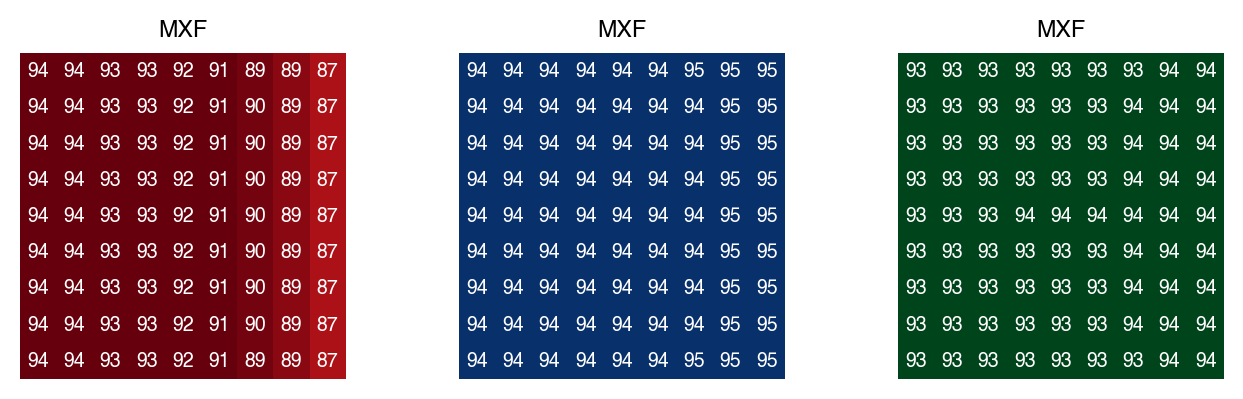

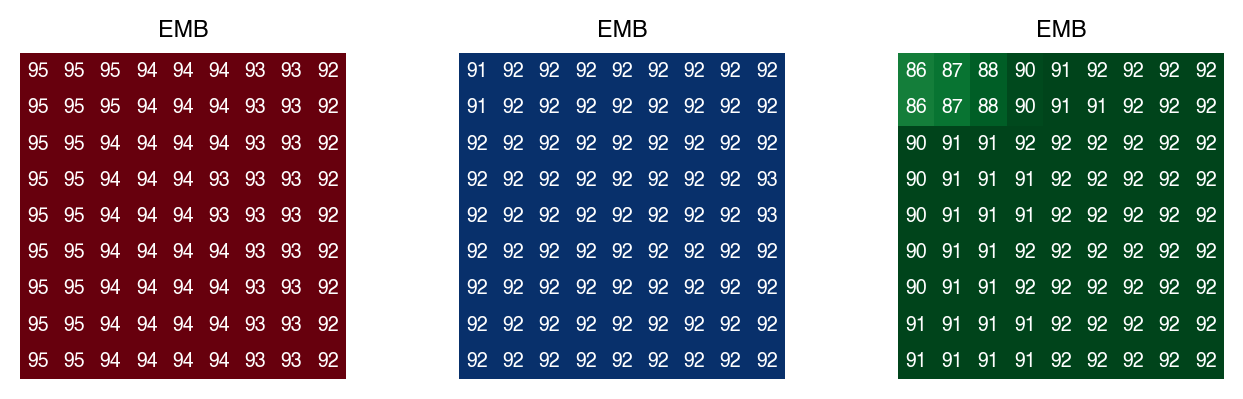

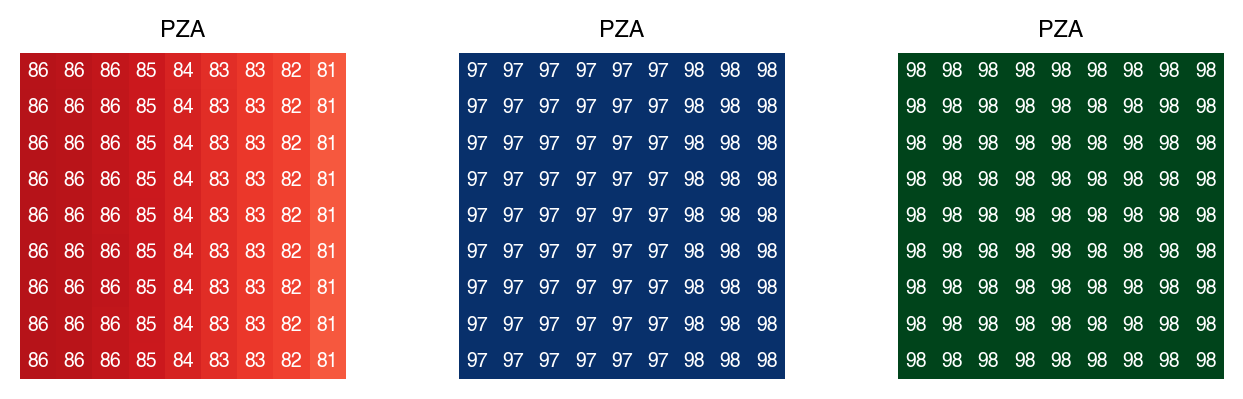

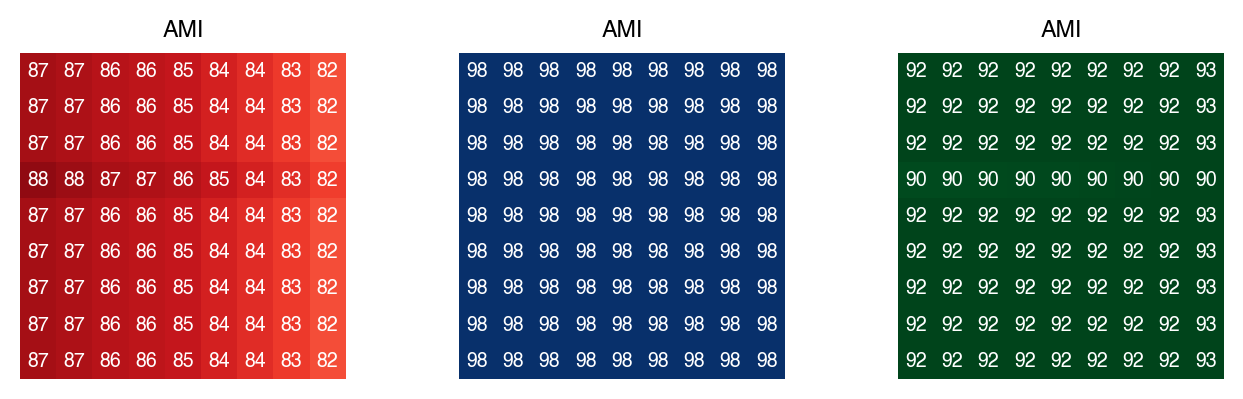

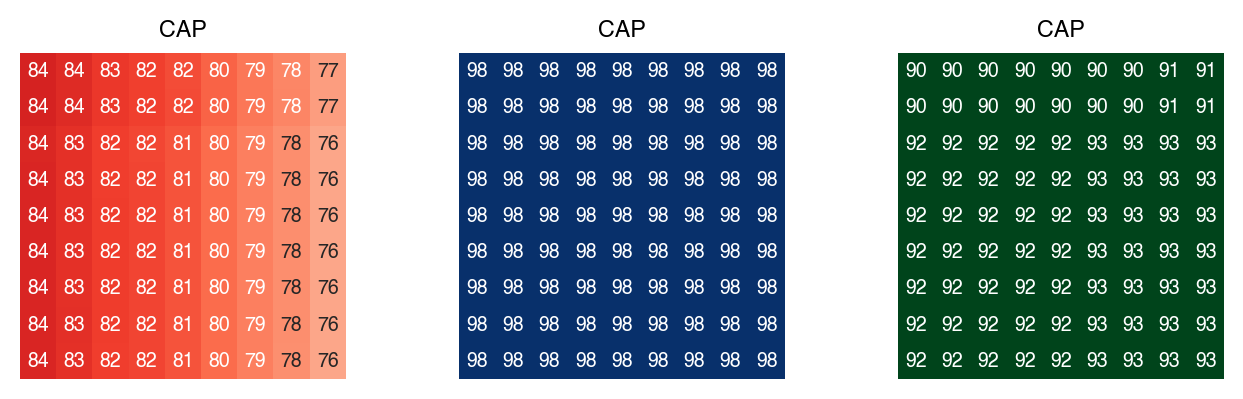

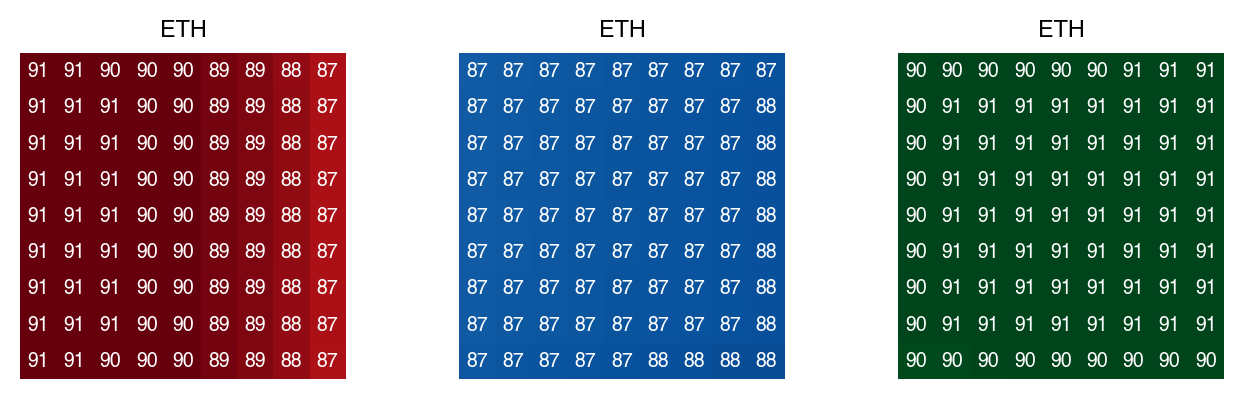

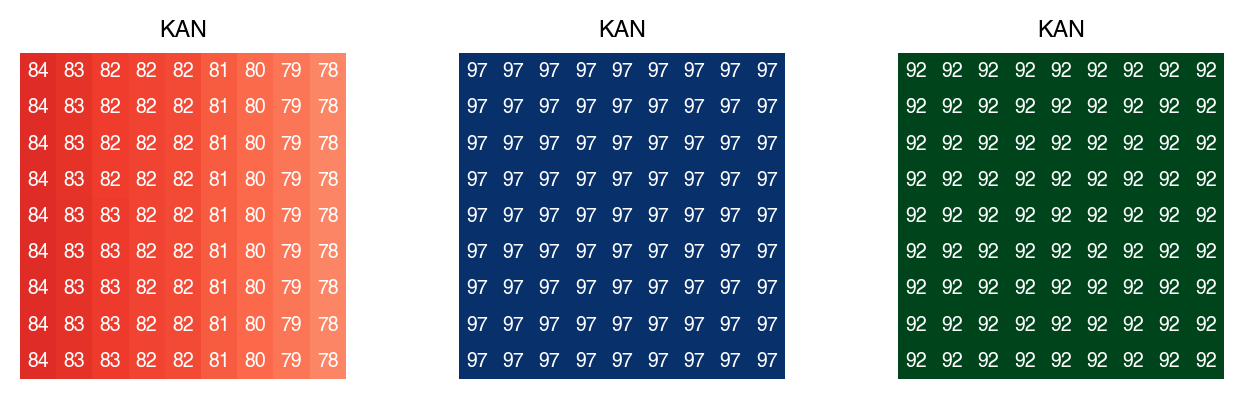

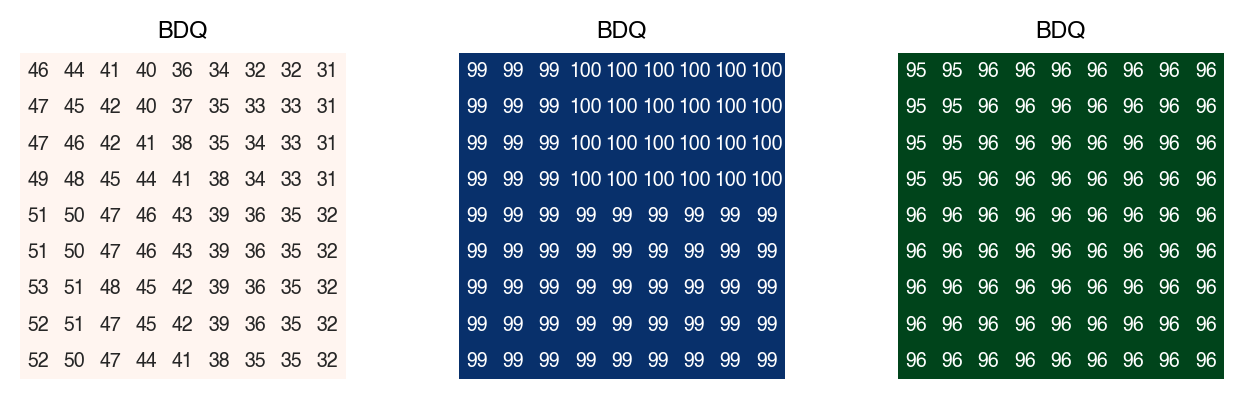

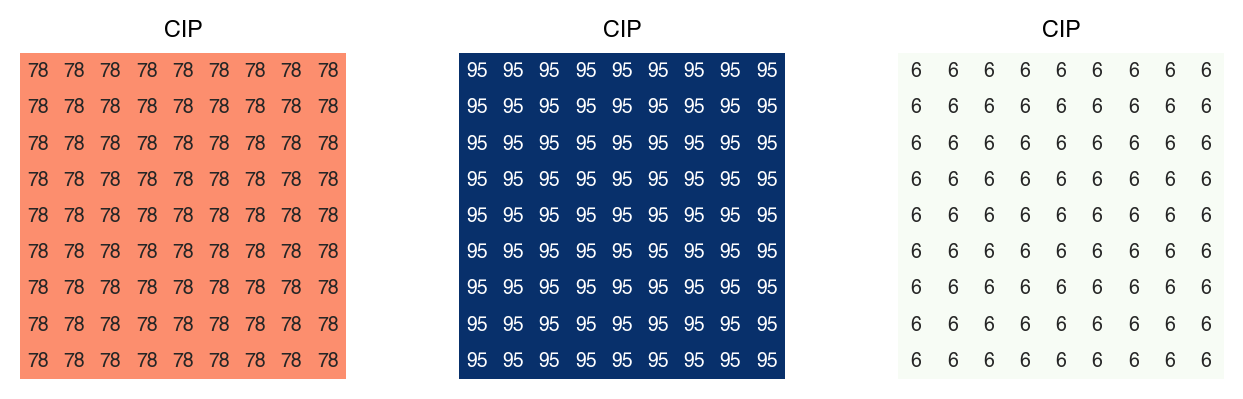

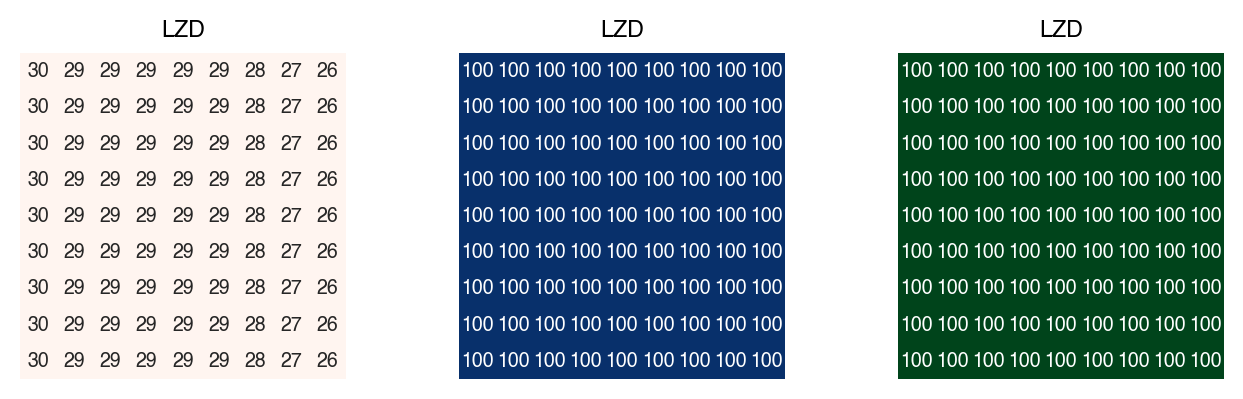

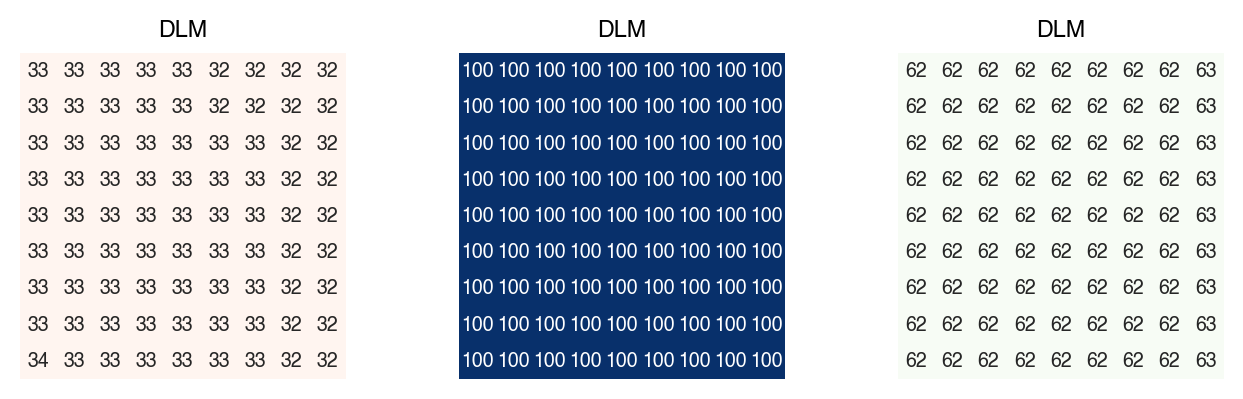

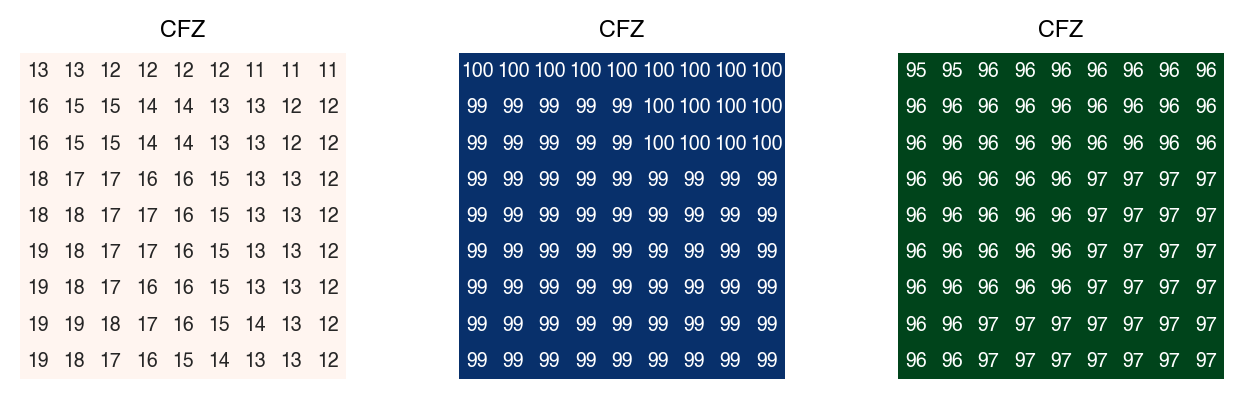

In [14]:
perf_df = perf_df.drop_duplicates(['Drug', 'Build_FRS', 'Test_FRS'], keep='first')
utils.plot_perf_heatmaps(perf_df, draw_axes=False)

## Confidence limit waterfall plots - analyse why performance changes by tracking mutations

### for mutations which are not consistently classified as R/S across different FRS thresholds for each drug.


In [15]:
varying_mutations = {}
for drug in perf_df.Drug.unique():
    muts = {}
    df = perf_df[perf_df.Drug == drug].reset_index()
    
    for i in df.drop_duplicates(['Build_FRS'], keep='first').index:
        background = opt_cats[opt_cats.DRUG == drug].BACKGROUND_RATE.values[0]
        p = opt_cats[opt_cats.DRUG == drug].p_value.values[0]
        build_FRS = df['Build_FRS'][i]
        catfile = f"./catalogues/MTBC-CRyPTICv1.1.1-2025.8/frs/{drug.lower()}/bg_{background}_p_{p}_FRS_{np.round(build_FRS,1)}.csv"
        cat = pd.read_csv(catfile)
        cat = cat[(cat.PREDICTION.isin(['R', 'S'])) & (~cat.MUTATION.str.contains(r'\*'))]
        muts[float(build_FRS)] = set(cat.MUTATION.values)  # Make them sets!

    all_muts_sets = list(muts.values())
    
    common_muts = set.intersection(*all_muts_sets)
    
    varying_muts = set.union(*all_muts_sets) - common_muts
    
    print(f"Drug: {drug}")
    print(f"Varying Mutations (changing across FRS):")
    print(varying_muts)
    print("-" * 40)
    varying_mutations[drug] = varying_muts


Drug: STM
Varying Mutations (changing across FRS):
{'gid@V65A', 'gid@52_del_c', 'gid@R96C', 'gid@26_del_ctgcgatcttcggaccgcggcttggccttgctcggcggtacgccgaagcgt', 'rrs@c1443g', 'gid@A200E', 'rrs@a906g'}
----------------------------------------
Drug: LEV
Varying Mutations (changing across FRS):
{'gyrA@D94C', 'gyrA@D94R', 'gyrB@E501D', 'gyrA@D94S', 'gyrB@N499K', 'gyrA@L105R'}
----------------------------------------
Drug: RIF
Varying Mutations (changing across FRS):
{'rpoB@H445N', 'rpoB@L449Q', 'rpoB@H445F', 'rpoB@D545E', 'rpoB@1297_del_ttcatggac', 'rpoB@L430P', 'rpoB@E761D', 'rpoB@M390T', 'rpoB@1301_del_tgg', 'rpoB@H445V', 'rpoB@H445P'}
----------------------------------------
Drug: INH
Varying Mutations (changing across FRS):
{'katG@W300G', 'katG@V473L', 'ahpC@V50G', 'inhA@N231D', 'katG@G299S', 'inhA@P251A', 'katG@P232R', 'ahpC@V49G', 'ahpC@c-54t', 'katG@Q461P', 'fabG1@c-60g', 'katG@V473F', 'katG@A172T', 'katG@Q439R', 'fabG1@T213P', 'ahpC@W53L', 'katG@D189N', 'katG@2005_ins_g', 'katG@A411D'

In [16]:
frs_prop_data = defaultdict(lambda: defaultdict(lambda: {'count': [], 'frs': [], 'y': [], 'error': []}))

to_float = lambda x: float(x) if isinstance(x, np.float64) else x

for drug, mutations in varying_mutations.items():  # <<-- use your new varying mutation dictionary
    background, p = opt_cats.loc[opt_cats.DRUG == drug, ['BACKGROUND_RATE', 'p_value']].iloc[0]
    print (drug)
    for frs in build_frs_values:
        # Load the catalogue
        catalogue = utils.load_catomatic_catalogue(
            drug, background, p, np.round(frs, 1), dir='catalogues/MTBC-CRyPTICv1.1.1-2025.8/frs/'
        )

        catalogue = catalogue[catalogue.EVIDENCE!={'seeded': 'True'}	]
        
        for field in ['PROPORTION', 'CONFIDENCE', 'CONTINGENCY']:
            catalogue[field] = catalogue['EVIDENCE'].apply(lambda x: utils.extract_value(x, field.lower()))

        catalogue['MUT_COUNT'] = catalogue['CONTINGENCY'].apply(lambda c: c[0][0] + c[0][1])
        # Filter only to relevant mutations (varying ones for this drug)
        catalogue_muts = catalogue[catalogue.MUTATION.isin(mutations)]

        def extract_errors(df, prop_col, conf_col):
            def clean_ci(ci):
                if isinstance(ci, list) and len(ci) == 2:
                    return [max(0, np.round(float(ci[0]), 3)), min(1, np.round(float(ci[1]), 3))] 
                return [np.nan, np.nan]

            prop = df[prop_col]
            err = df[conf_col].apply(clean_ci)

            if len(prop) > 1:
                return (np.array(prop).flatten(), np.vstack(err))
            elif len(prop) == 1:
                return (np.array(prop).flatten(), np.stack(err.values).T)
            else:
                return (np.array(prop).flatten(), err.to_numpy())
        #pull out confidence limits and proportions of ressitance for each mutation from the catalogue
        prop, error = extract_errors(catalogue_muts, 'PROPORTION', 'CONFIDENCE')

        # Save required data for plotting
        for i, mutation in enumerate(catalogue_muts.MUTATION.tolist()):
            mut_count = catalogue_muts.iloc[i]['MUT_COUNT']  # Get count per mutation for current FRS
            frs_prop_data[drug][mutation]['frs'].append(to_float(frs))
            frs_prop_data[drug][mutation]['y'].append(prop[i])
            frs_prop_data[drug][mutation]['count'].append(mut_count)  # ✅ Store count per FRS

            frs_prop_data[drug][mutation]['error'].append(error[i] if prop.shape[0] > 1 else error)
            frs_prop_data[drug][mutation]['background'] = background

# Make final dict cleaner
frs_prop_data = {drug: dict(mutations) for drug, mutations in frs_prop_data.items()}


STM
LEV
RIF
INH
MXF
EMB
PZA
AMI
CAP
ETH
KAN
BDQ
CIP
LZD
DLM
CFZ


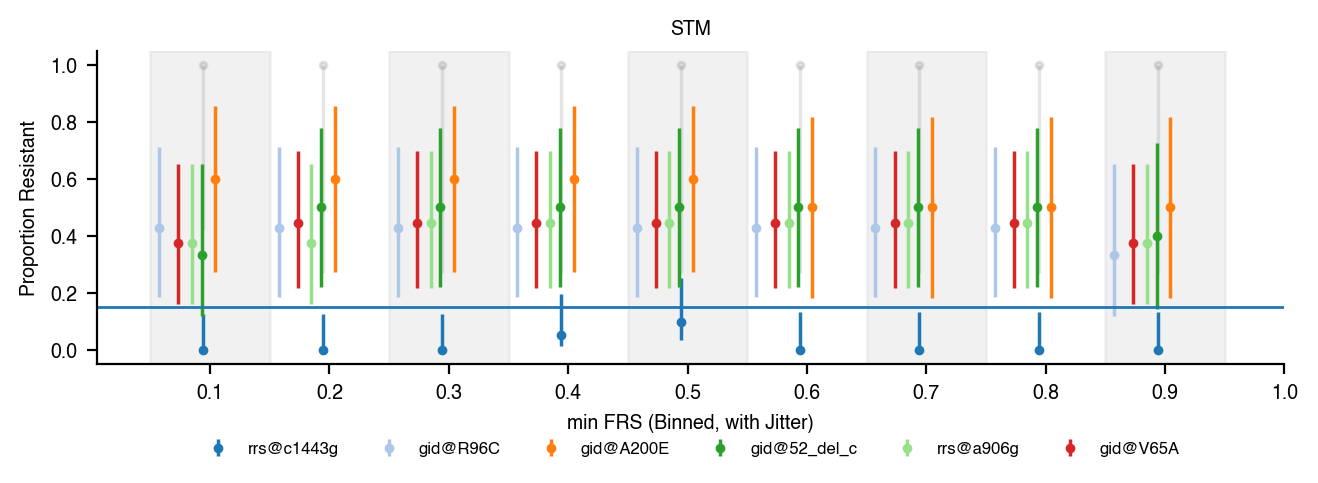

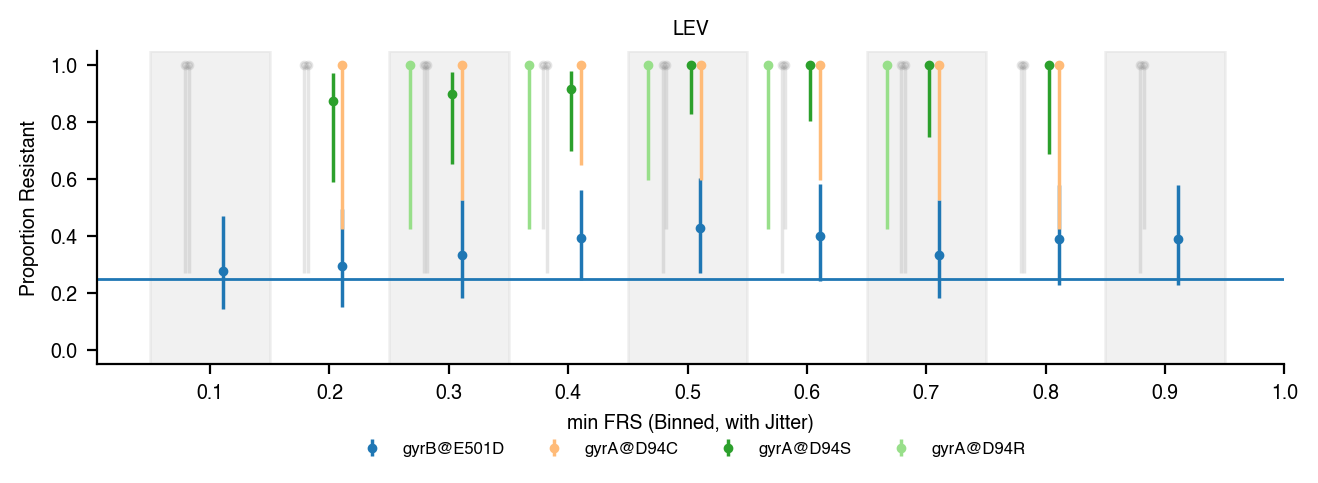

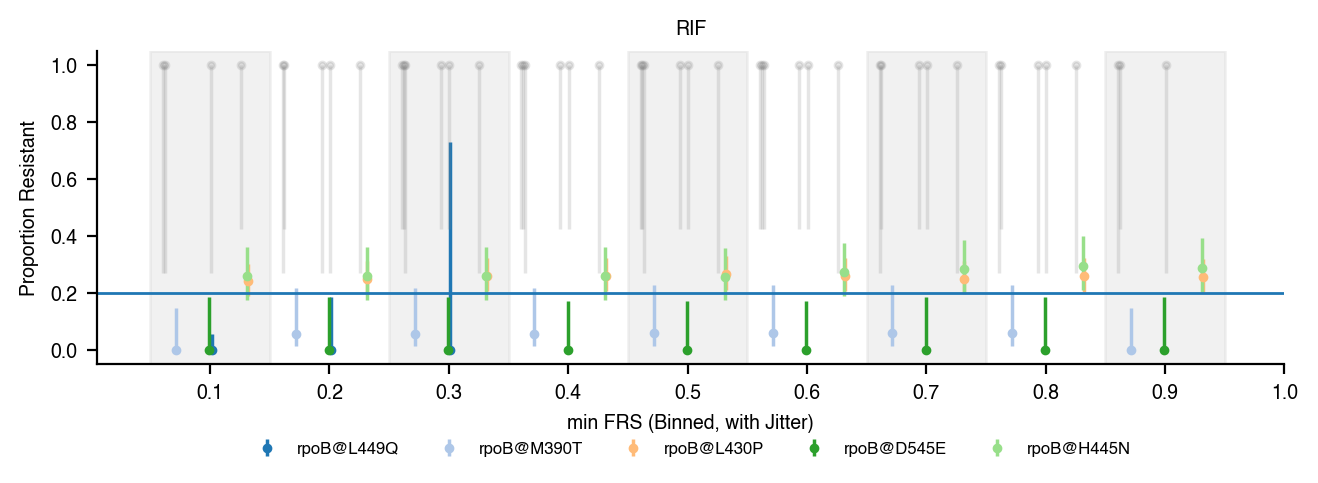

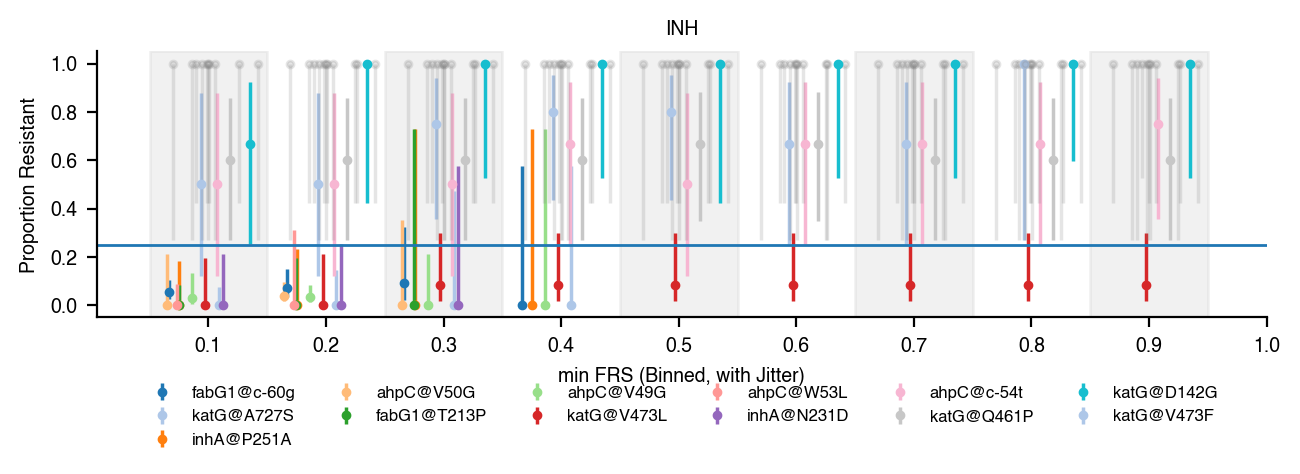

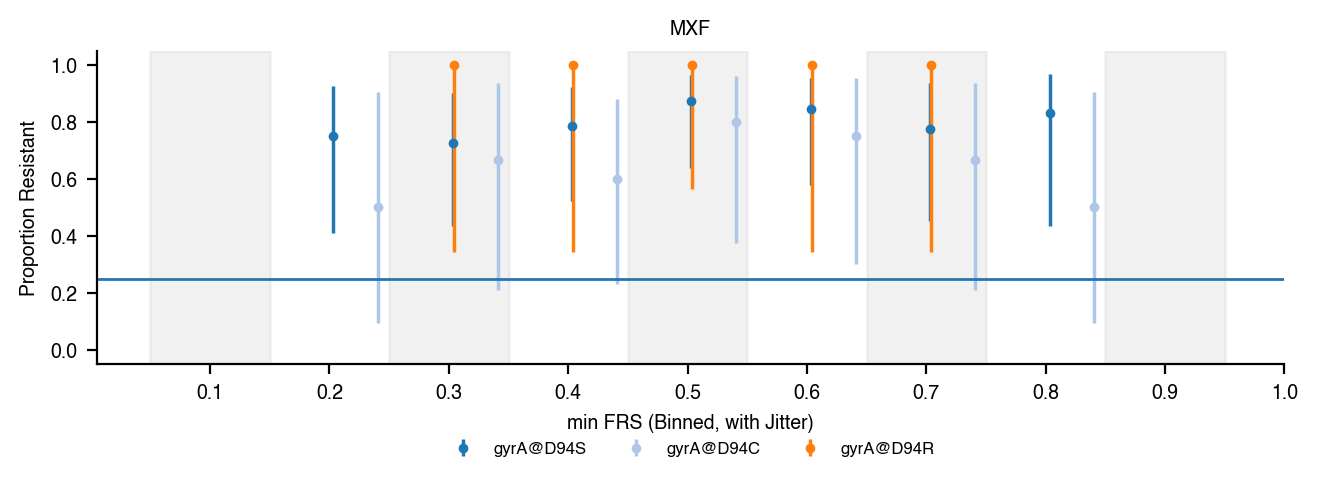

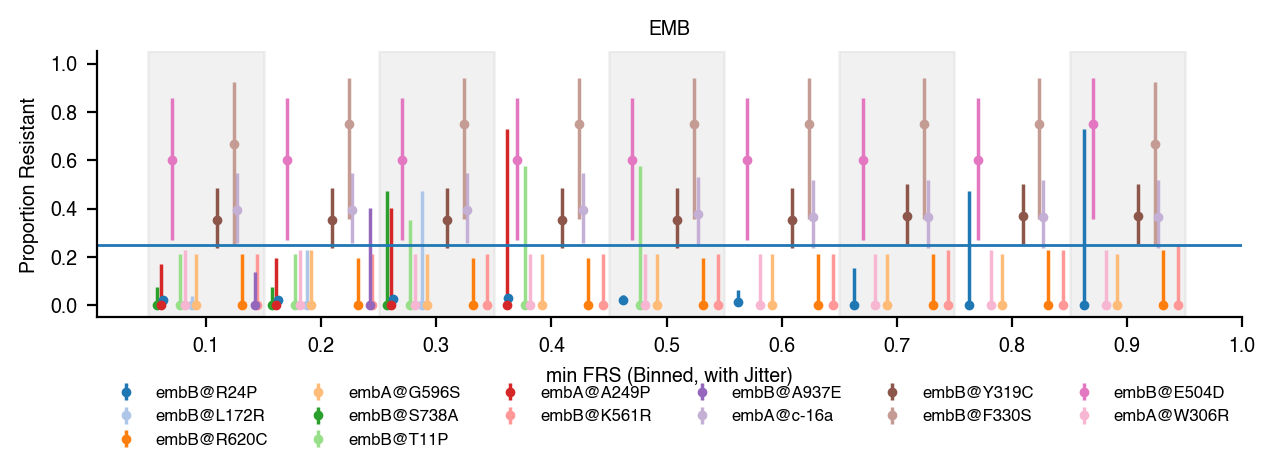

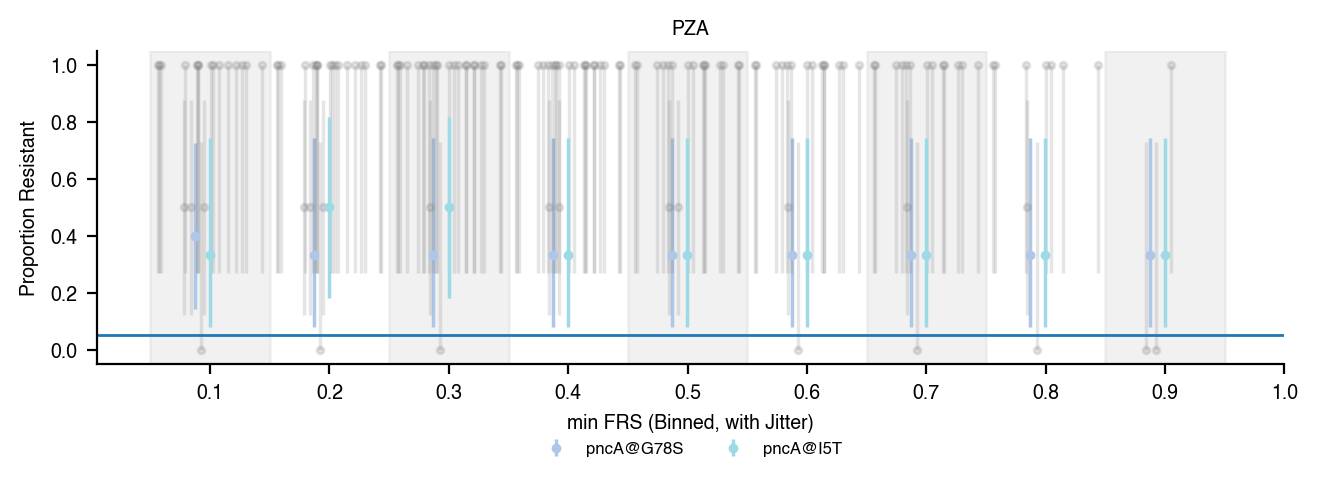

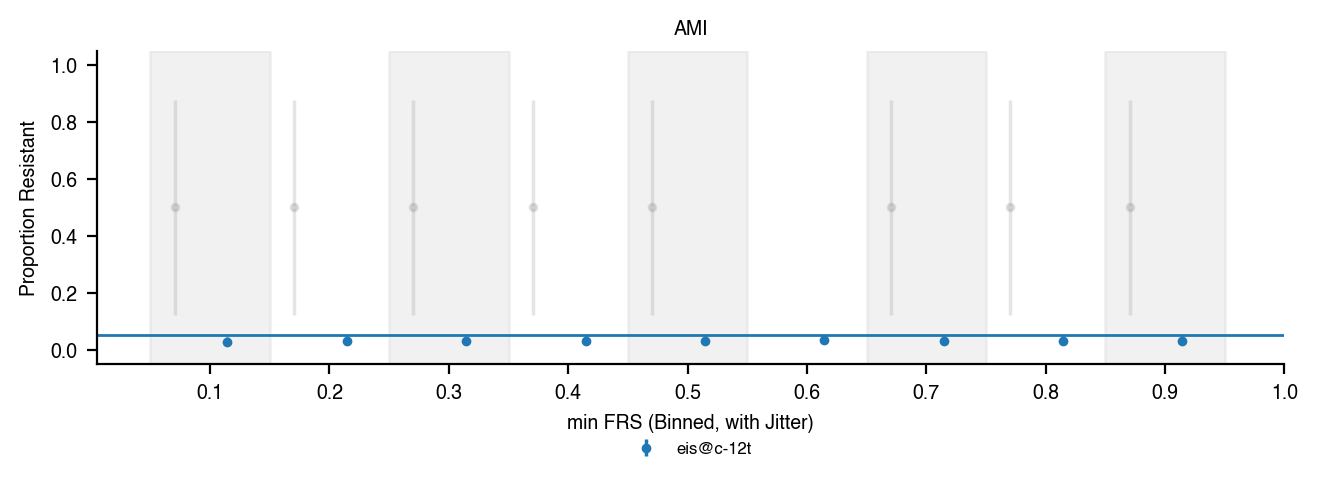

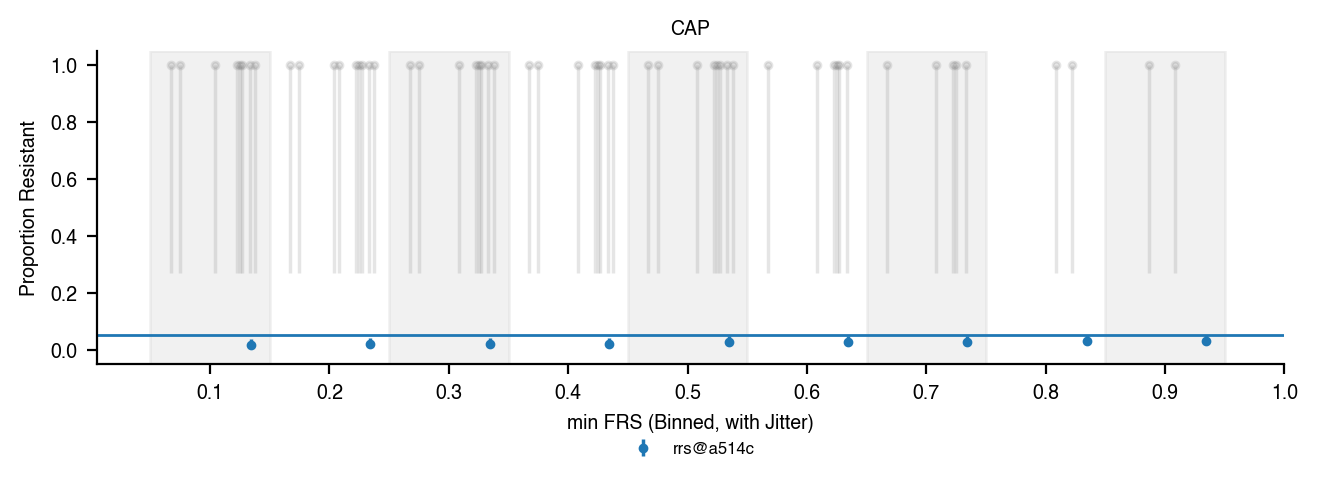

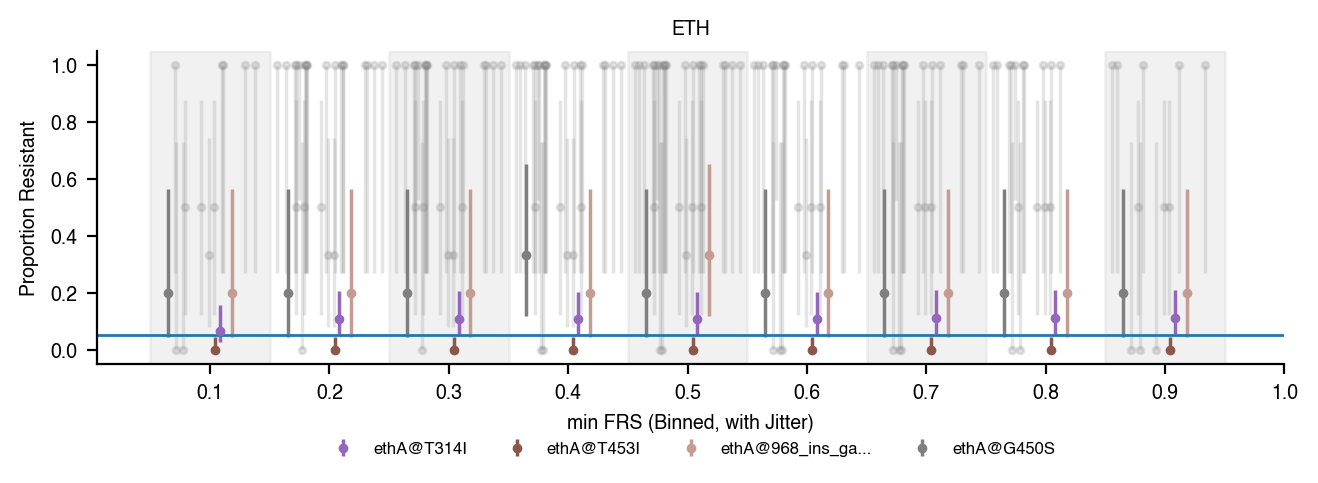

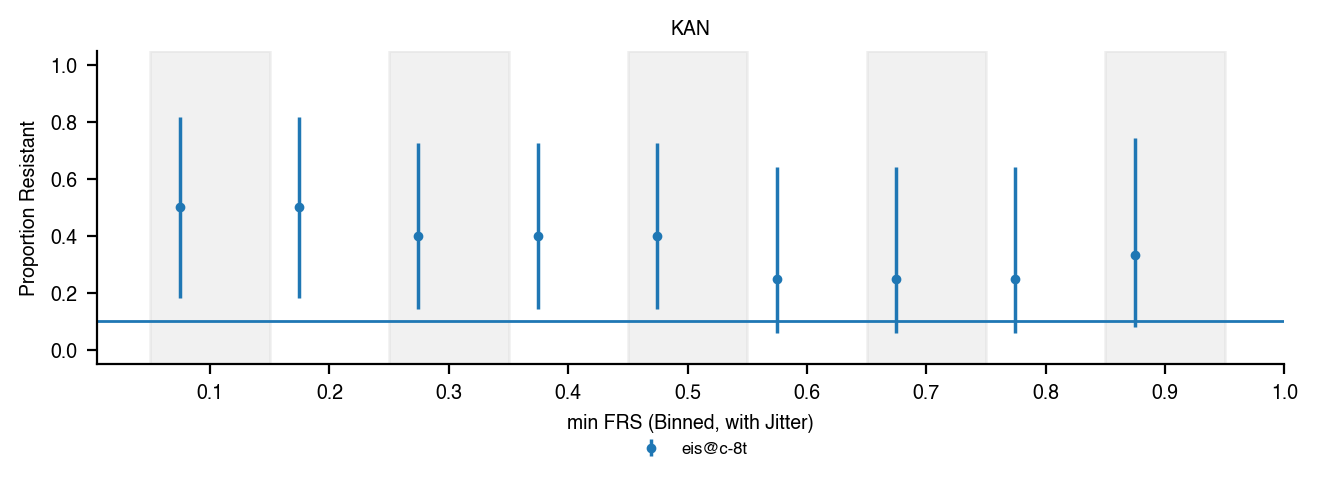

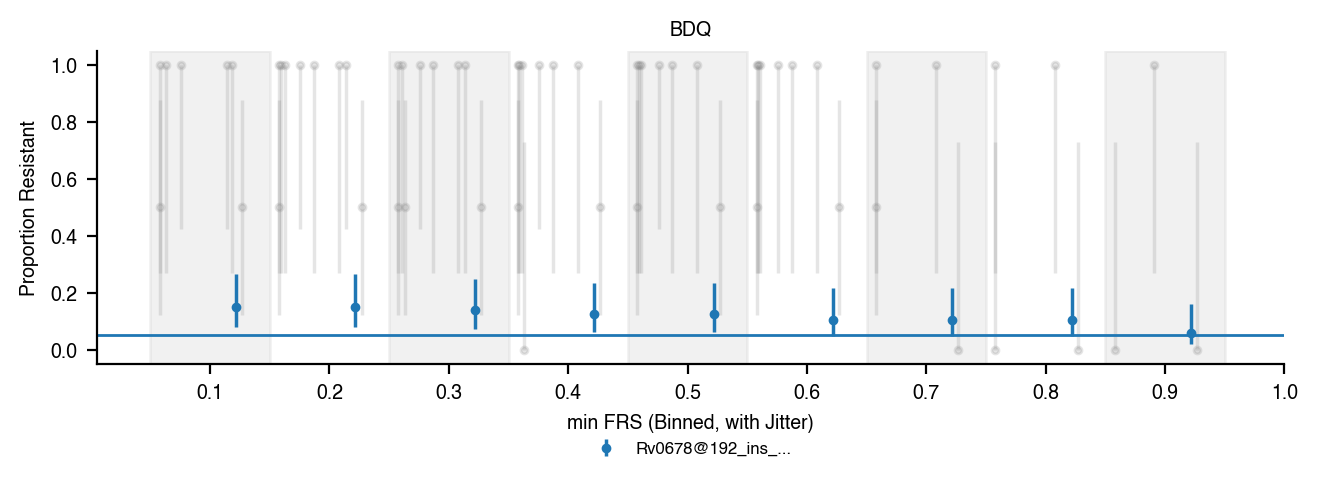

/Users/dylanadlard/Documents/Oxford/PhD/Projects/cryptic-catalogues-2025/protocols/graphs.py:392: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(


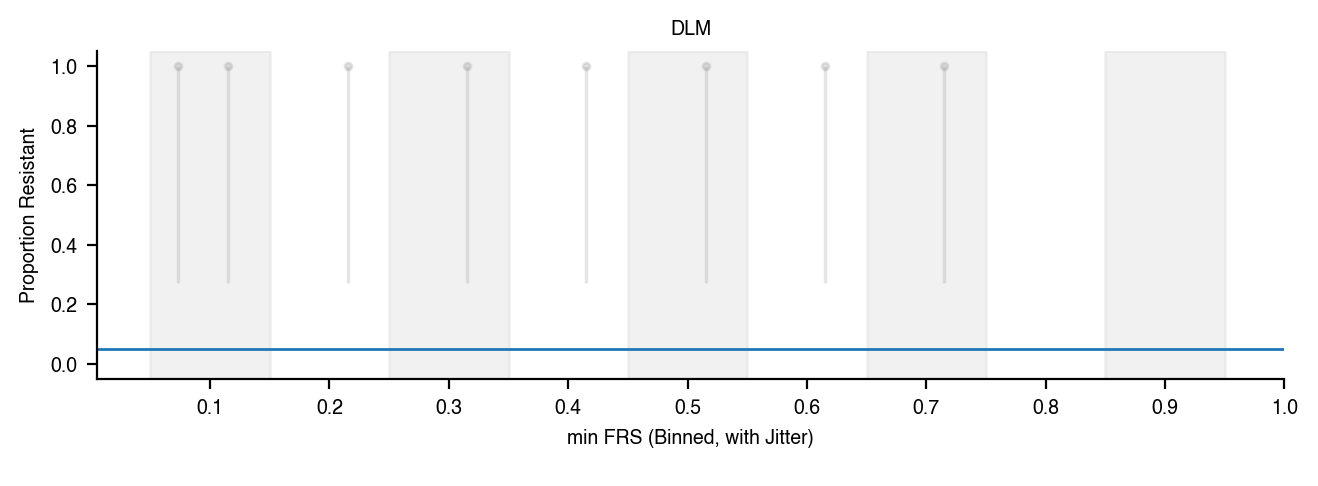

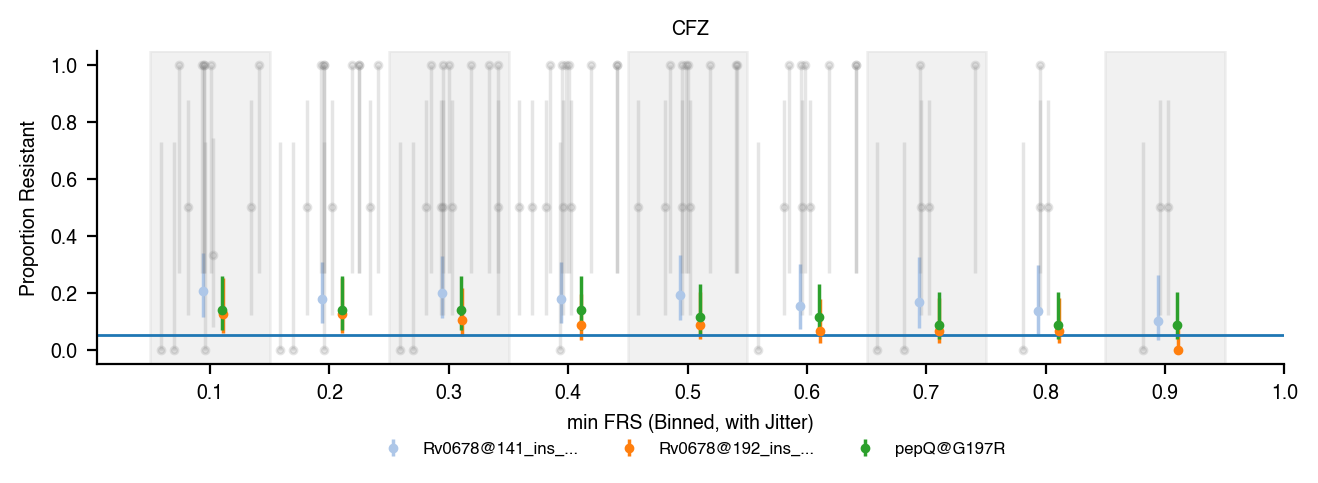

In [17]:
color_map = {}
for drug, mutations_dict in frs_prop_data.items():
    unique_mutations = list(mutations_dict.keys())
    color_map[drug] = dict(zip(unique_mutations, sns.color_palette("tab20", len(unique_mutations))))

graphs.plot_mutation_error_bars(frs_prop_data, color_map=color_map, min_err=1, figpath='figs/frs/')

# Investigate the burden of minor alleles 

## FRS distribution vs essential/non-essential violin plots

In [18]:
#read in phylogenetic mutations (doi:  10.1186/s13073-020-00726-5)
phylogenetics = pd.read_csv('data/13073_2020_726_MOESM3_ESM (4).csv')
phylogenetics['MUTATION'] = phylogenetics['GeneName'] + '@' + phylogenetics['group_subst'].str.split(' ').str[0]
phylogenetics

,# group_id,ref,pos,gene,GeneName,annotation,category,PureSNP,group_allel,number_group_strains,...,pheno-S that are geno-R,pheno-S minus geno-R,pheno-R,pheno-R that are geno-R,pheno-R minus geno-R,true S + unexplained R,(true S)/(true S+unexplained R),ratio >0.9 = neutral,comment,MUTATION
0,group_311,G,5072,-,gyrB_upstream,-,-,1.0,T,2.0,...,NaN,NaN,NaN,NaN,NaN,NaN,no data,NaN,NaN,gyrB_upstream@5072
1,group_290,C,5075,-,gyrB_upstream,-,-,1.0,T,11.0,...,NaN,NaN,NaN,NaN,NaN,NaN,no data,NaN,NaN,gyrB_upstream@5075
2,group_329,A,5082,-,gyrB_upstream,-,-,0.0,GAP,2.0,...,NaN,NaN,NaN,NaN,NaN,NaN,no data,NaN,NaN,gyrB_upstream@5082_GAP
3,group_330,C,5671,Rv0005,gyrB,DNA gyrase (subunit B) GyrB (DNA topoisomerase...,essential,1.0,T,3.0,...,NaN,NaN,NaN,NaN,NaN,NaN,no data,NaN,NaN,gyrB@Y144Y
4,group_327,G,5752,Rv0005,gyrB,DNA gyrase (subunit B) GyrB (DNA topoisomerase...,essential,1.0,A,8.0,...,NaN,NaN,NaN,NaN,NaN,NaN,no data,NaN,NaN,gyrB@V171V
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
543,unique strain,C,737857,Rv0643c,mmaA3,Methoxy mycolic acid synthase 3 MmaA3 (methyl ...,essential,1.0,A,1.0,...,NaN,NaN,NaN,NaN,NaN,NaN,no data,NaN,NaN,mmaA3@G98D
544,group_302,wt,NaN,Rv1979c,Rv1979c,Possible conserved permease,nonessential,0.0,deleted,18.0,...,NaN,NaN,NaN,NaN,NaN,NaN,no data,NaN,convergent evolution by (partial) deletion of ...,Rv1979c@uncovered
545,unique strain,wt,NaN,Rv1979c,Rv1979c,Possible conserved permease,nonessential,0.0,deleted,2.0,...,NaN,NaN,NaN,NaN,NaN,NaN,no data,NaN,convergent evolution by (partial) deletion of ...,Rv1979c@partially
546,unique strain,wt,NaN,Rv1979c,Rv1979c,Possible conserved permease,nonessential,0.0,deleted,1.0,...,NaN,NaN,NaN,NaN,NaN,NaN,no data,NaN,convergent evolution by (partial) deletion of ...,Rv1979c@uncovered


In [19]:
#define essential and non-essnetial genes (doi: 10.1186/s13073-020-00726-5)
essential = {'essential':["rpoB", "gyrA", "gyrB", "rplC", "dprE1", "atpE",  "rpsL", 'rrs', "embA", "embB",], 'non_essential':["eis", "tlyA", "pepQ", "inhA", "ethA", "ahpC", "katG", "ddn", "pncA", "Rv0678", "gid", "fabG1"]}
#import mutations and prep catalogues for each gene
for type, genes in essential.items():
    mutations = functions.prep_mutations('data/mutations-v3.4.0/', 
                                        genes, 
                                        version='v3.4.0', 
                                        mut_path=cryptic_tables_path+'MUTATIONS.parquet', 
                                        var_path=cryptic_tables_path+'VARIANTS.parquet', 
                                        train=True)
    #mutations = mutations[~mutations.MUTATION.isin([v for d in drug_genes.values() for v in d['phylogenetic']])]
    catalogue = pd.read_csv('catalogues/MTBC-CRyPTICv1.1.1-2025.8.csv')
    #mutations = mutations[mutations.MUTATION.isin(catalogue[catalogue.PREDICTION=='R'].MUTATION.values)]
    mutations = mutations[~mutations.MUTATION.isin(phylogenetics.MUTATION.values)]
    mutations['GENE'] = [i.split('@')[0] for i in mutations.MUTATION]
    #mutations = mutations[mutations.FRS<=0.9]
    if type=='essential':
        essential_frs = mutations.FRS.tolist()
        essential_gene_list = mutations.GENE.tolist()
    elif type=='non_essential':
        non_essential_frs = mutations.FRS.tolist()
        non_essential_gene_list = mutations.GENE.tolist()
    


0 Essential
1 Non-Essential


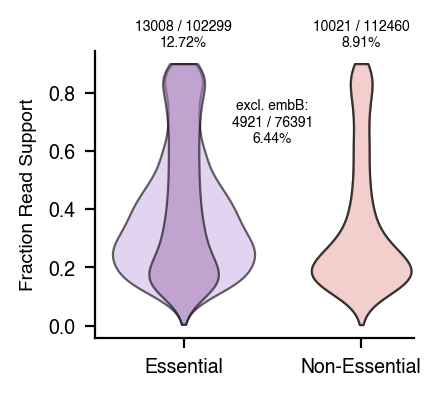

In [20]:
# Create base dataframe
data = pd.DataFrame({
    "Read Support": essential_frs + non_essential_frs,
    "Gene Category": ["Essential"] * len(essential_frs) + ["Non-Essential"] * len(non_essential_frs),
    "Gene": essential_gene_list + non_essential_gene_list# This assumes you have these lists
})

graphs.FRS_essential_violins(data)

In [21]:
# Define threshold for minor alleles
threshold = 0.9

# Count mutations below threshold
minor_essential = np.sum(np.array(essential_frs) <= threshold)
minor_nonessential = np.sum(np.array(non_essential_frs) <= threshold)

# Total number of mutations in each group
total_essential = len(essential_frs)
total_nonessential = len(non_essential_frs)

# Run the two-proportion z-test
count = [minor_essential, minor_nonessential]
nobs = [total_essential, total_nonessential]

stat, pval = proportions_ztest(count, nobs, alternative='smaller')

print(f"Essential minor alleles: {minor_essential} / {total_essential}")
print(f"Non-essential minor alleles: {minor_nonessential} / {total_nonessential}")
print(f"Z-statistic: {stat:.3f}")
print(f"P-value: {pval}")

Essential minor alleles: 13011 / 102299
Non-essential minor alleles: 10021 / 112460
Z-statistic: 28.483
P-value: 1.0


## Plot frs vs gene violin plots

To constrict to R alleles only, just comment back in the filter below

In [22]:
essential = {'essential':["rpoB", "gyrA", "gyrB", "rplC", "dprE1", "atpE",  "rpsL", 'rrs', "embA", "embB",], 'non_essential':["eis", "tlyA", "pepQ", "inhA", "ethA", "ahpC", "katG", "ddn", "pncA", "Rv0678", "gid", "fabG1"]}

combined_data = []

for cat, genes in essential.items():
    mutations = functions.prep_mutations(
        'data/mutations-v3.4.0/',
        genes,
        version='v3.4.0',
        mut_path=cryptic_tables_path + 'MUTATIONS.parquet',
        var_path=cryptic_tables_path + 'VARIANTS.parquet',
        train=True
    )
    #mutations = mutations[~mutations.MUTATION.isin([v for d in drug_genes.values() for v in d['phylogenetic']])]
    catalogue = pd.read_csv('catalogues/MTBC-CRyPTICv1.1.1-2025.8.csv')
    #mutations = mutations[mutations.MUTATION.isin(catalogue[catalogue.PREDICTION=='R'].MUTATION.values)]
    mutations = mutations[~mutations.MUTATION.isin(phylogenetics.MUTATION.values)]

    mutations['GENE'] = mutations['MUTATION'].str.split('@').str[0]
    mutations['Category'] = "Essential" if cat == 'essential' else "Non-Essential"
    combined_data.append(mutations[['GENE', 'FRS', 'Category']])
    

rpoB: 1640/31612 = 5.19%
gyrA: 1381/12180 = 11.34%
gyrB: 408/4558 = 8.95%
rplC: 128/738 = 17.34%
dprE1: 105/1623 = 6.47%
atpE: 21/87 = 24.14%
rpsL: 281/11067 = 2.54%
rrs: 566/9130 = 6.20%
embA: 391/5396 = 7.25%
embB: 8087/25908 = 31.21%
eis: 630/4328 = 14.56%
tlyA: 220/940 = 23.40%
pepQ: 345/1128 = 30.59%
inhA: 154/1615 = 9.54%
ethA: 848/10357 = 8.19%
ahpC: 2525/10769 = 23.45%
katG: 1078/21388 = 5.04%
ddn: 112/880 = 12.73%
pncA: 1329/13952 = 9.53%
Rv0678: 943/2941 = 32.06%
gid: 947/36607 = 2.59%
fabG1: 890/7555 = 11.78%


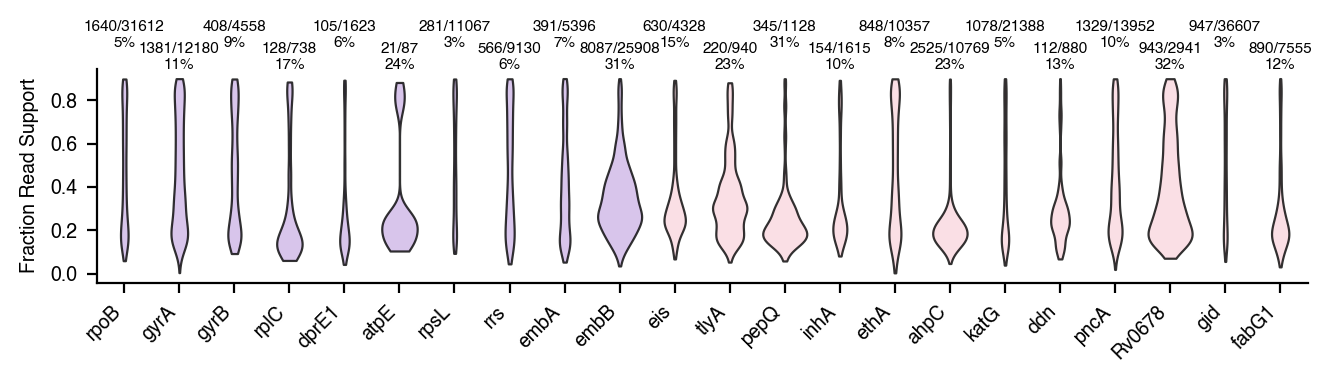

In [23]:
# Concatenate all mutations
all_mutations = pd.concat(combined_data)

graphs.frs_gene_violins(all_mutations)